In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
!pip install tensorflow_hub
import tensorflow_hub as hub
!pip install --upgrade imbalanced-learn scikit-learn
from imblearn.over_sampling import RandomOverSampler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/ae/20/6d1a0a61d468b37a142fd90bb93c73bc1c2205db4a69ac630ed218c31612/scikit_learn-1.5.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for threadpoolctl>=2.0.0 from https://files.pythonhosted.org/packages/4b/2c/ffbf7a134b9ab11a67b0cf0726453cedd9c5043a4fe7a35d1cefa9a1bcfb/threadpoolctl-3.5.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB 991.0 kB/s eta 0:00:12
    --------------------------------------- 0.2/11.0 MB 1.8 MB/s eta 0:00:06
    --------------------------------------- 0.3/11.0 MB 2.3 MB/s eta 0:00:05
   - -------------------------------------- 0.5/11.0 MB 3.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.7/11.0 MB 3.2 MB/s eta 0:00:04
   --- ------------------------------------ 0.9/11.0 MB 3.3 MB/s eta 0:00:04
   --- -----------------------

ImportError: cannot import name '_check_X' from 'imblearn.utils._validation' (C:\Users\Lim Otto\anaconda3\Lib\site-packages\imblearn\utils\_validation.py)

In [6]:
file = "C:\\Users\\Lim Otto\\Downloads\\diabetes.csv"
df = pd.read_csv(file)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.corr()["Outcome"]

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

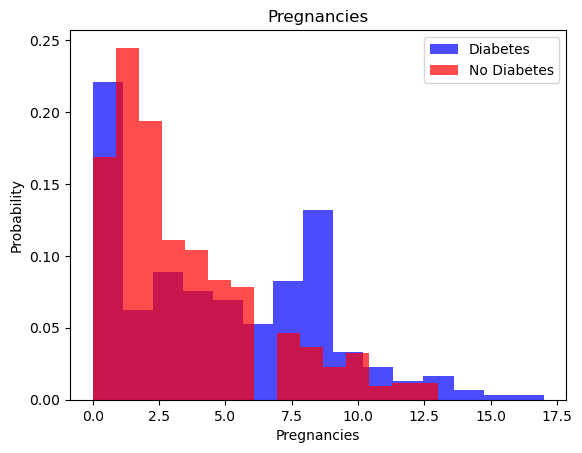

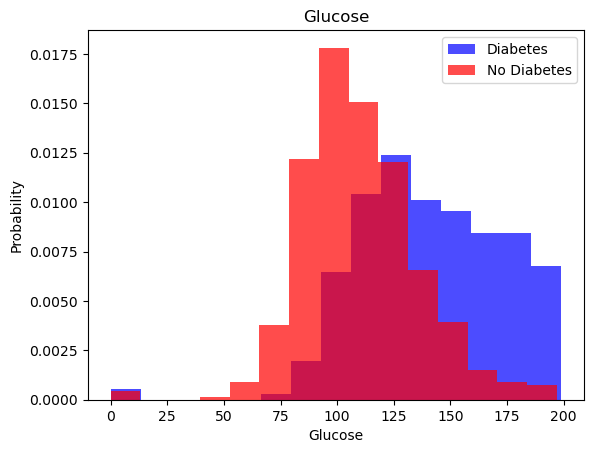

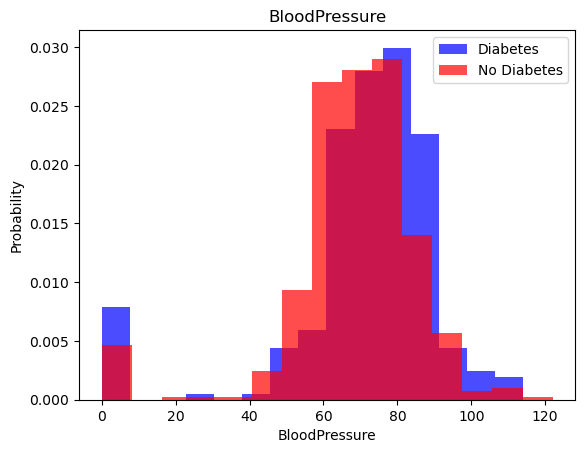

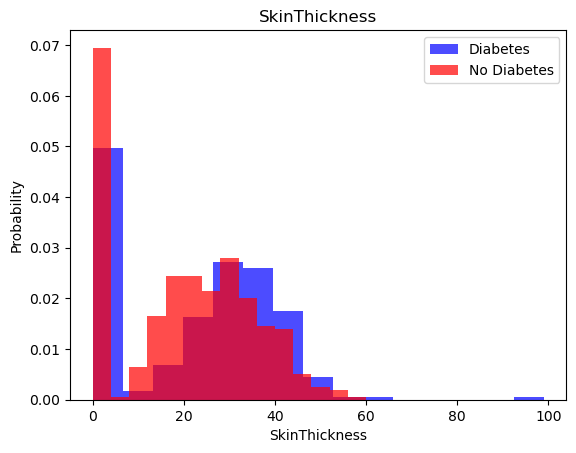

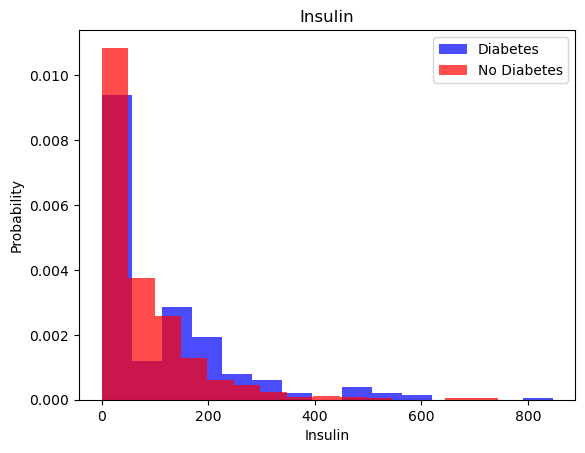

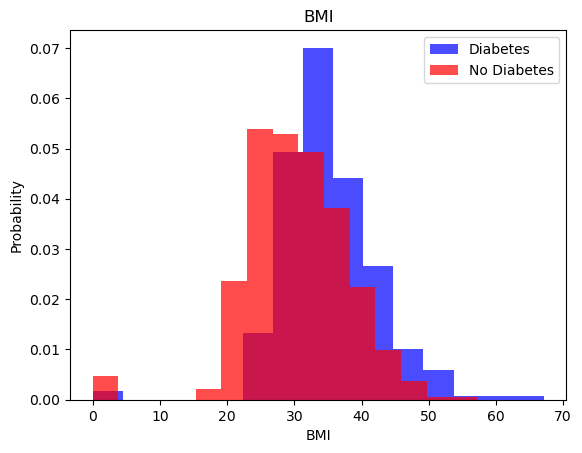

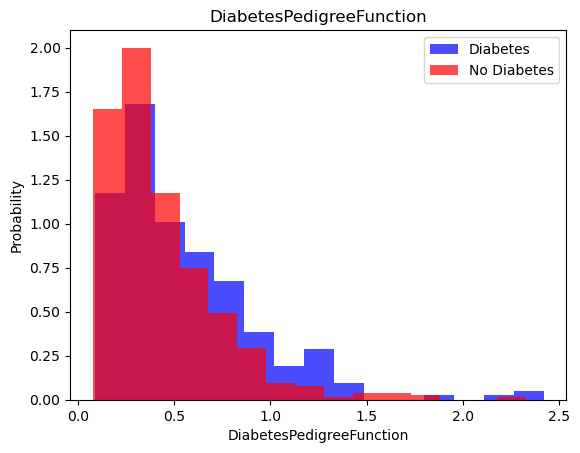

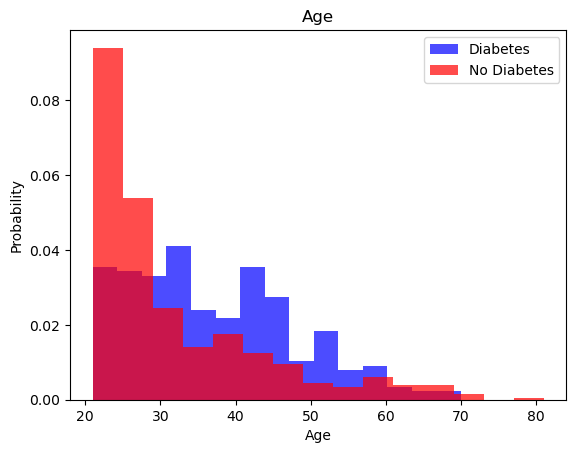

In [14]:
for i in range(len(df.columns[:-1])):
    label = df.columns[i]
    plt.hist(df[df['Outcome']==1][label], color='blue', label='Diabetes', alpha=0.7, density=True, bins=15)
    plt.hist(df[df['Outcome']==0][label], color='red', label='No Diabetes', alpha=0.7, density=True, bins=15)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)  
    plt.legend()
    plt.show()

In [28]:
#Assigning X and y variable
X = df[df.columns[:-1]].values
y = df[df.columns[-1]].values

In [31]:
#Noticed different dimentions on both var
X.shape, y.shape

((768, 8), (768,))

In [32]:
#Scaling/normalize the features to improve current model accuracy of 0.6
scaler = StandardScaler()
X = scaler.fit_transform(X)
data = np.hstack((X, np.reshape(y, (-1, 1))))
transformed_df = pd.DataFrame(data, columns=df.columns)

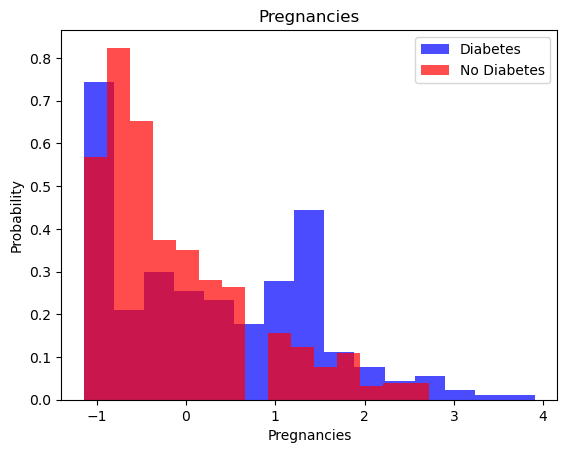

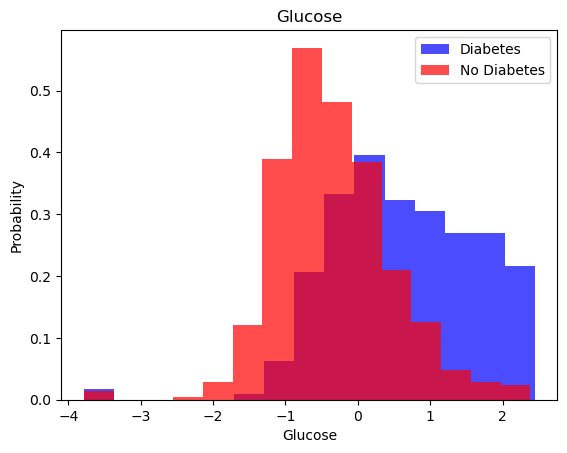

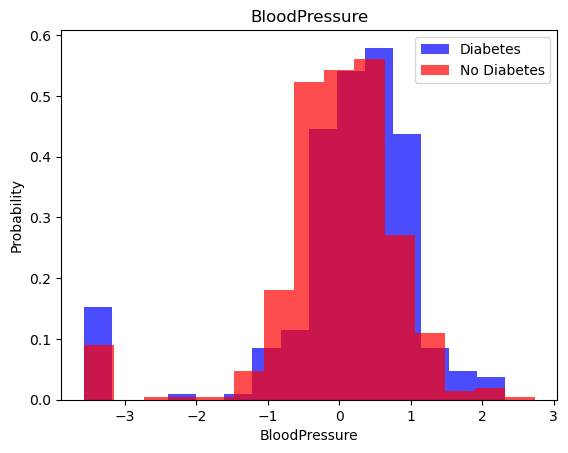

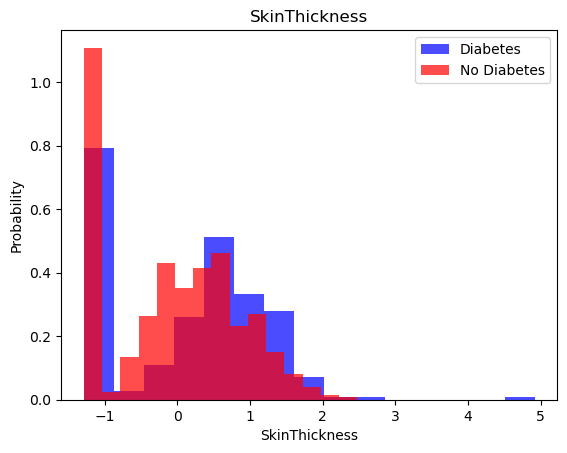

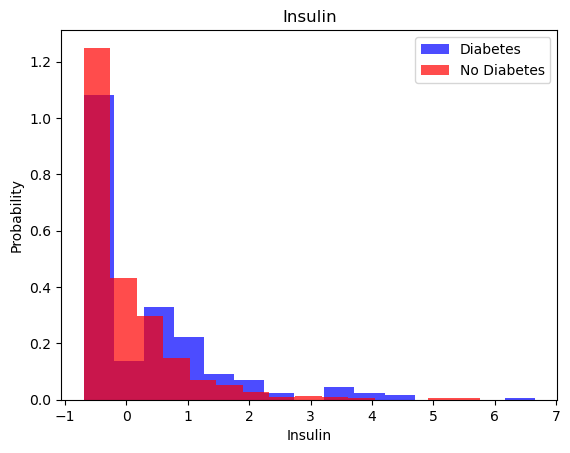

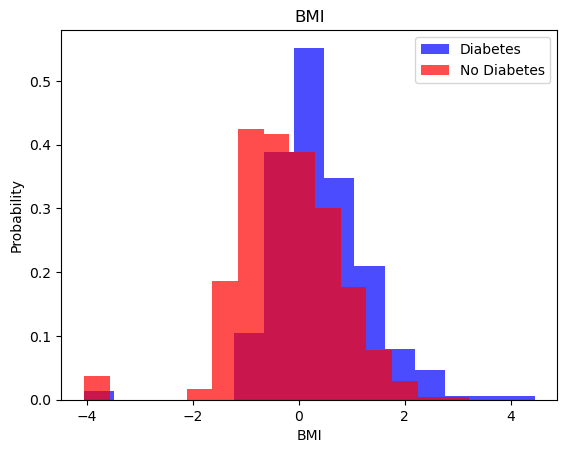

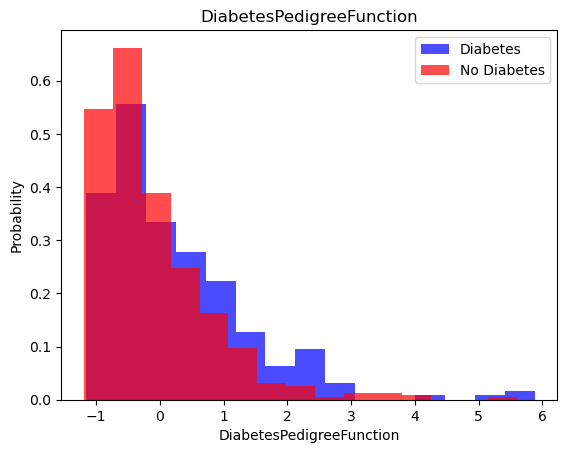

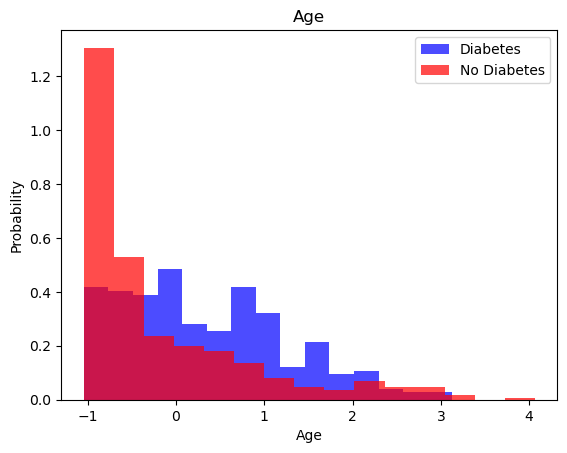

In [33]:
#Visualized the transformed and scalled df
for i in range(len(df.columns[:-1])):
    label = df.columns[i]
    plt.hist(transformed_df[transformed_df['Outcome']==1][label], color='blue', label='Diabetes', alpha=0.7, density=True, bins=15)
    plt.hist(transformed_df[transformed_df['Outcome']==0][label], color='red', label='No Diabetes', alpha=0.7, density=True, bins=15)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)  
    plt.legend()
    plt.show()

In [19]:
#Splitting var for training, validation and test set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=0)

In [20]:
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

In [22]:
#Structuring the neuro net model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [23]:
model.compile(optimizer='adam', 
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [24]:
#initial stage, evaluating model
model.evaluate(X_train, y_train)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4747 - loss: 8.4253  


[8.223021507263184, 0.4847826063632965]

In [25]:
model.evaluate(X_valid, y_valid)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4124 - loss: 9.0767  


[8.833868980407715, 0.4220779240131378]

In [26]:
#Accuracy were low at 0.4 before training
#Training the model now
model.fit(X_train, y_train, batch_size=16, epochs=20, validation_data= (X_valid, y_valid))

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4992 - loss: 6.1990 - val_accuracy: 0.5519 - val_loss: 2.1329
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5881 - loss: 1.6925 - val_accuracy: 0.6234 - val_loss: 1.2278
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5865 - loss: 1.5225 - val_accuracy: 0.6039 - val_loss: 1.0936
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6661 - loss: 1.1655 - val_accuracy: 0.6429 - val_loss: 0.9530
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6618 - loss: 0.8459 - val_accuracy: 0.6039 - val_loss: 0.9570
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6534 - loss: 0.8201 - val_accuracy: 0.6169 - val_loss: 0.7834
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5996 - loss: 0.8889 - val_accuracy: 0.6364 - val_loss: 0.7797
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6570 - loss: 0.8008 - val_accuracy: 0.5195 - val_loss:

In [35]:
#Outcome value difference is huge suggesting imbalance input for training, this affects the ML accuracy
len(df[df['Outcome']==1]), len(df[df['Outcome']==0])

(268, 500)

In [51]:
#Solving the imbalance by RandomOverSampler
#!pip install --upgrade scikit-learn

from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler()
X, y = over.fit_resample(X, y)


ImportError: cannot import name '_check_X' from 'imblearn.utils._validation' (C:\Users\Lim Otto\anaconda3\Lib\site-packages\imblearn\utils\_validation.py)

In [52]:
#Accuracy increased after normalization 
model.evaluate(X_train, y_train)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7197 - loss: 0.5894 


[0.6240671277046204, 0.70652174949646]

In [55]:
#2nd round training
model.fit(X_train, y_train, batch_size=16, epochs=20, validation_data= (X_valid, y_valid))

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7009 - loss: 0.6424 - val_accuracy: 0.7013 - val_loss: 0.6454
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6783 - loss: 0.6869 - val_accuracy: 0.7013 - val_loss: 0.6366
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7002 - loss: 0.6203 - val_accuracy: 0.6558 - val_loss: 0.6761
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6592 - loss: 0.7486 - val_accuracy: 0.6623 - val_loss: 0.7187
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6579 - loss: 0.6416 - val_accuracy: 0.6494 - val_loss: 0.7170
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7334 - loss: 0.6052 - val_accuracy: 0.6429 - val_loss: 0.6324
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6839 - loss: 0.6261 - val_accuracy: 0.6883 - val_loss: 0.6444
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5982 - loss: 0.7799 - val_accuracy: 0.7078 - val_loss:

In [ ]:
#The accuracy increased but not as expected due to RandomOverSampling couldnt be done to regulate both outcome =1, =0 var to equal 500 value each
#Sad- spending 1hr debugging and troubleshoot but no luck


In [56]:
#Acc around 66% due to the both outcome =1, =0 is approx 1/3, Hence,
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6570 - loss: 0.7335 


[0.6502714157104492, 0.6753246784210205]